# Show Labeled Frame

Load one DLC-labeled frame from a project and overlay its keypoints.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from modules.label_csv_utils import load_keypoints

In [2]:
project_path = Path("projects/rat")
video_name = "2025-03-18 12-58-10"
frame_idx = 6

In [5]:
csv_path = project_path / "labeled-data" / video_name / "CollectedData_rats.csv"
keypoints_df = load_keypoints(csv_path)

frame_row = keypoints_df.loc[keypoints_df["frame"] == int(frame_idx)]
if frame_row.empty:
    raise ValueError(f"Frame {frame_idx} not found in {csv_path}")

frame_row = frame_row.iloc[0]
padding_width = keypoints_df.attrs.get("dlc_frame_padding_width", 3)
image_name = f"img{int(frame_idx):0{padding_width}d}.png"
image_path = project_path / "labeled-data" / video_name / image_name

if not image_path.exists():
    raise FileNotFoundError(image_path)

image = Image.open(image_path)

points = []
for col in keypoints_df.columns[1:]:
    if not col.endswith("_x"):
        continue
    bodypart = col[:-2]
    x = frame_row[f"{bodypart}_x"]
    y = frame_row.get(f"{bodypart}_y")
    if pd.isna(x) or pd.isna(y):
        continue
    points.append((bodypart, int(x), int(y)))

print(f"image_path: {image_path}")
print(f"image_size: {image.size}")
print(f"visible_keypoints: {len(points)}")

image_path: projects\rat\labeled-data\2025-03-18 12-58-10\img006.png
image_size: (1280, 720)
visible_keypoints: 12


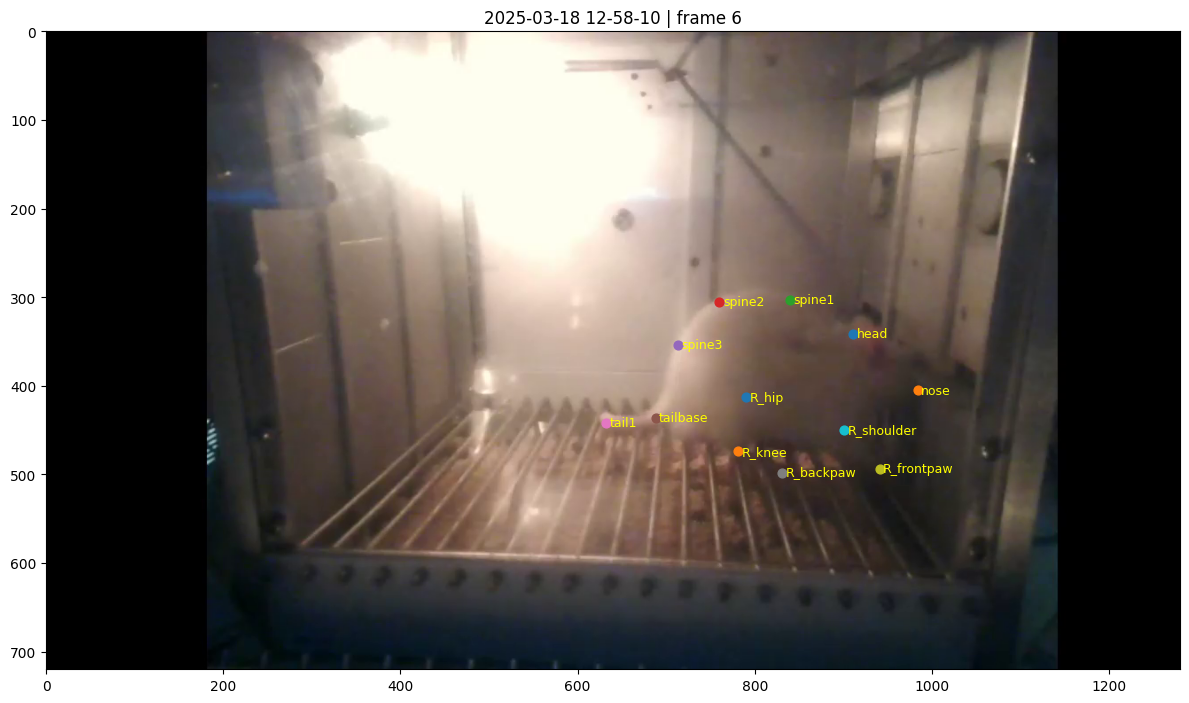

In [6]:
plt.figure(figsize=(12, 7))
plt.imshow(image)

for bodypart, x, y in points:
    plt.scatter(x, y, s=40)
    plt.text(x + 4, y + 4, bodypart, fontsize=9, color="yellow")

plt.title(f"{video_name} | frame {frame_idx}")
plt.xlim(0, image.size[0])
plt.ylim(image.size[1], 0)
plt.tight_layout()
plt.show()